In [115]:
import numpy as np
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw

In [3]:
pdf = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv')
# pdf = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv') #for stevie

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_46363/518615070.py:1: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  pdf = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv')


In [4]:
#convert to datetime
pdf['DATE'] = pd.to_datetime(pdf['DATE'],format = 'mixed')
pdf = pdf.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon (I found one cycle on a float that was causing these errors)

#fix lat lon values with '--' (replace with nan) (no longer needed since I found the problem float)
# pdf['LATITUDE'] = pd.to_numeric(pdf['LATITUDE'], errors='coerce')
# pdf['LONGITUDE'] = pd.to_numeric(pdf['LONGITUDE'], errors='coerce')


In [5]:
#create season columns
pdf["year"] = pdf["DATE"].dt.year.astype("Int64")
pdf["month"] = pdf["DATE"].dt.month.astype("Int64")

def assign_season(row):
    m = int(row["month"])
    y = int(row["year"])
    if m >= 9:
        return f"{y}-{y+1}"
    elif m <= 4:
        return f"{y-1}-{y}"
    else:
        return f"{y}"

pdf["season"] = pdf.apply(assign_season, axis=1)

In [52]:
#convert to datetime
pdf['DATE'] = pd.to_datetime(pdf['DATE'],format = 'mixed')
#add year and month columns
pdf["year"] = pdf["DATE"].dt.year
pdf["month"] = pdf["DATE"].dt.month

# Define a season label: if month >=10 then season = year-year+1, else if month <=3 then season = (year-1)-year
def assign_season(row):
    m = row["month"]
    y = row["year"]
    if m >= 8:         # Aug, Sept, Oct, Nov, Dec
        return f"{y}-{y+1}"
    elif m <= 4:        # Jan, Feb, Mar
        return f"{y-1}-{y}"
    else:
        return f"{y}"   # outside the austral productive season (Apr-Sep)

#subset data with good QC only
qc_flags = [1,2,8]
pdf_clean = pdf[pdf['CHLA_ADJUSTED_QC'].isin(qc_flags) & pdf['BBP700_ADJUSTED_QC'].isin(qc_flags) & pdf['DOXY_ADJUSTED_QC'].isin(qc_flags) & pdf['PSAL_ADJUSTED_QC'].isin(qc_flags)]


In [6]:
pdf

,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,PRES,...,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season
0,0,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,6.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,8,2013
1,1,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,8,2013
2,2,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,14.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,8,2013
3,3,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,19.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,8,2013
4,4,1901135,174,A,2013-08-23 01:13:44.999978,1,-62.053,150.025,1,24.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,8,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1519016,1519016,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1600.10,...,1.0,1.311489,7.856922,3.0,7.838748,1.0,0.014984,2025,10,2025-2026
1519017,1519017,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1699.80,...,1.0,1.311867,7.858857,3.0,7.840679,1.0,0.014990,2025,10,2025-2026
1519018,1519018,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1799.52,...,1.0,1.312243,7.861394,3.0,7.843212,1.0,0.014996,2025,10,2025-2026
1519019,1519019,7902154,16,A,2025-10-16 06:34:24.000693,1,-58.1553,174.3372,1,1900.15,...,1.0,1.312737,7.864672,3.0,7.846485,1.0,0.015004,2025,10,2025-2026


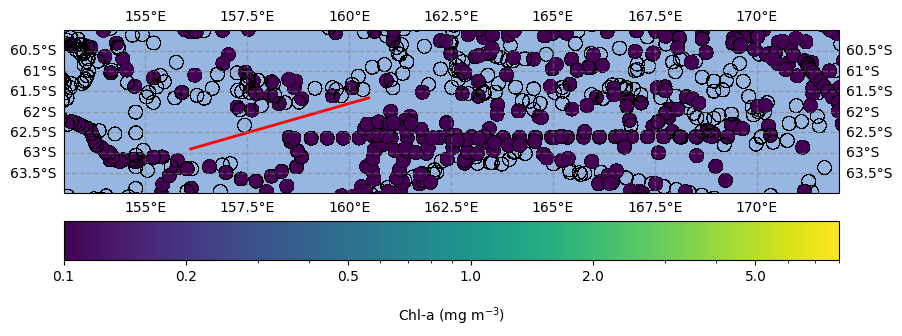

In [32]:
# things to fix: colorbar obviously, also how to make it just surface chla concentrations not the whole profile depth


fig = plt.figure(figsize=(10, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)

sc = ax.scatter(pdf['LONGITUDE'], pdf['LATITUDE'], c=pdf['CHLA_ADJUSTED'], cmap='viridis', norm=LogNorm(vmin=0.1, vmax=8), edgecolor='k',linewidth=0.1, s=100)

# Define start and end points for KR1 and KR2
start_lon1, start_lat1 = 151.33, -60.24
end_lon1, end_lat1 = 153.08, -59.89
start_lon2, start_lat2 = 156.12, -62.91
end_lon2, end_lat2 = 160.48, -61.66

# Plot diagonal line on map
ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=2, linestyle='-', transform=ccrs.PlateCarree())
ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=2, linestyle='-', transform=ccrs.PlateCarree())

ax.set_extent([153, 172, -60, -64], crs=ccrs.PlateCarree()) # just data region

lat = [-63.164055, -62.79286]
lon = [163.932868, 169.976922]
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.03)
cbar.set_label('Chl-a (mg m$^{-3}$)', labelpad=15)
cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
cbar.formatter = FormatStrFormatter("%.1f")
cbar.update_ticks()

plt.show()

In [118]:
 # writing function
def subset_yr(df, yr1,yr2):
    
    subset = df[df['year'].isin([yr1,yr2])]
    # add subset by the productive months
    subset = subset[subset['month'].isin([1,2,3,4,8,9, 10,11,12])]
    
    return subset

pdf_yr = subset_yr(pdf,2014,2015)
pdf_yr

,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,PRES,...,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season
423,423,1901155,145,A,2015-01-02 04:48:22.000017,1,-59.747,169.637,1,4.40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,1,2014-2015
424,424,1901155,145,A,2015-01-02 04:48:22.000017,1,-59.747,169.637,1,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,1,2014-2015
425,425,1901155,145,A,2015-01-02 04:48:22.000017,1,-59.747,169.637,1,16.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,1,2014-2015
426,426,1901155,145,A,2015-01-02 04:48:22.000017,1,-59.747,169.637,1,30.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,1,2014-2015
427,427,1901155,145,A,2015-01-02 04:48:22.000017,1,-59.747,169.637,1,40.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,1,2014-2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545191,545191,5904598,39,A,2015-12-27 09:15:51.000987,1,-63.714,150.346,1,1798.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,2015-2016
545192,545192,5904598,39,A,2015-12-27 09:15:51.000987,1,-63.714,150.346,1,1847.83,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,2015-2016
545193,545193,5904598,39,A,2015-12-27 09:15:51.000987,1,-63.714,150.346,1,1897.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,2015-2016
545194,545194,5904598,39,A,2015-12-27 09:15:51.000987,1,-63.714,150.346,1,1947.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,2015-2016


In [117]:
 # writing function - can use to look at all data from productive month from one season (use function, then make depth profiles)
 # maybe work on how to make function that makes depth profiles instead of maps!
def subset_yr(df, season):
    
    subset = df[df['season'].isin([season])]
    # add subset by the productive months
    subset = subset[subset['month'].isin([1,2,3,4,8,9,10,11,12])]
    
    return subset

pdf_yr = subset_yr(pdf,'2014.0-2015.0') # make sure you have in quotes and exact wording
pdf_yr

,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,PRES,...,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season


In [132]:
#convert to datetime
pdf['DATE'] = pd.to_datetime(pdf['DATE'],format = 'mixed')
#add year and month columns
pdf["year"] = pdf["DATE"].dt.year
pdf["month"] = pdf["DATE"].dt.month

# Define a season label: if month >=10 then season = year-year+1, else if month <=3 then season = (year-1)-year
def assign_season(row):
    m = row["month"]
    y = row["year"]
    if m >= 8:         # Aug, Sept, Oct, Nov, Dec
        return f"{y}-{y+1}"
    elif m <= 4:        # Jan, Feb, Mar
        return f"{y-1}-{y}"
    else:
        return f"{y}"   # outside the austral productive season (Apr-Sep)

#subset data with good QC only
qc_flags = [1,2,8]
pdf_clean = pdf[pdf['CHLA_ADJUSTED_QC'].isin(qc_flags) & pdf['BBP700_ADJUSTED_QC'].isin(qc_flags) & pdf['DOXY_ADJUSTED_QC'].isin(qc_flags) & pdf['PSAL_ADJUSTED_QC'].isin(qc_flags)]

pdf_clean["season"] = pdf_clean.apply(assign_season, axis=1)


/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_46363/775759699.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf_clean["season"] = pdf_clean.apply(assign_season, axis=1)


In [133]:
# Condition 1: July-Dec 2014
cond1 = (pdf_clean['year'] == 2014) & (pdf_clean['month'] >= 7)

# Condition 2: Jan-June 2015
cond2 = (pdf_clean['year'] == 2015) & (pdf_clean['month'] <= 6)

# Combine them with "OR" (|)
subset_df = pdf_clean[cond1 | cond2]
subset_df['month']

376487    7
376490    7
376494    7
376497    7
376501    7
         ..
472894    6
472920    6
472946    6
472972    6
472987    6
Name: month, Length: 4734, dtype: int32

In [134]:
df = subset_df[subset_df['WMOID'] == 5904104]

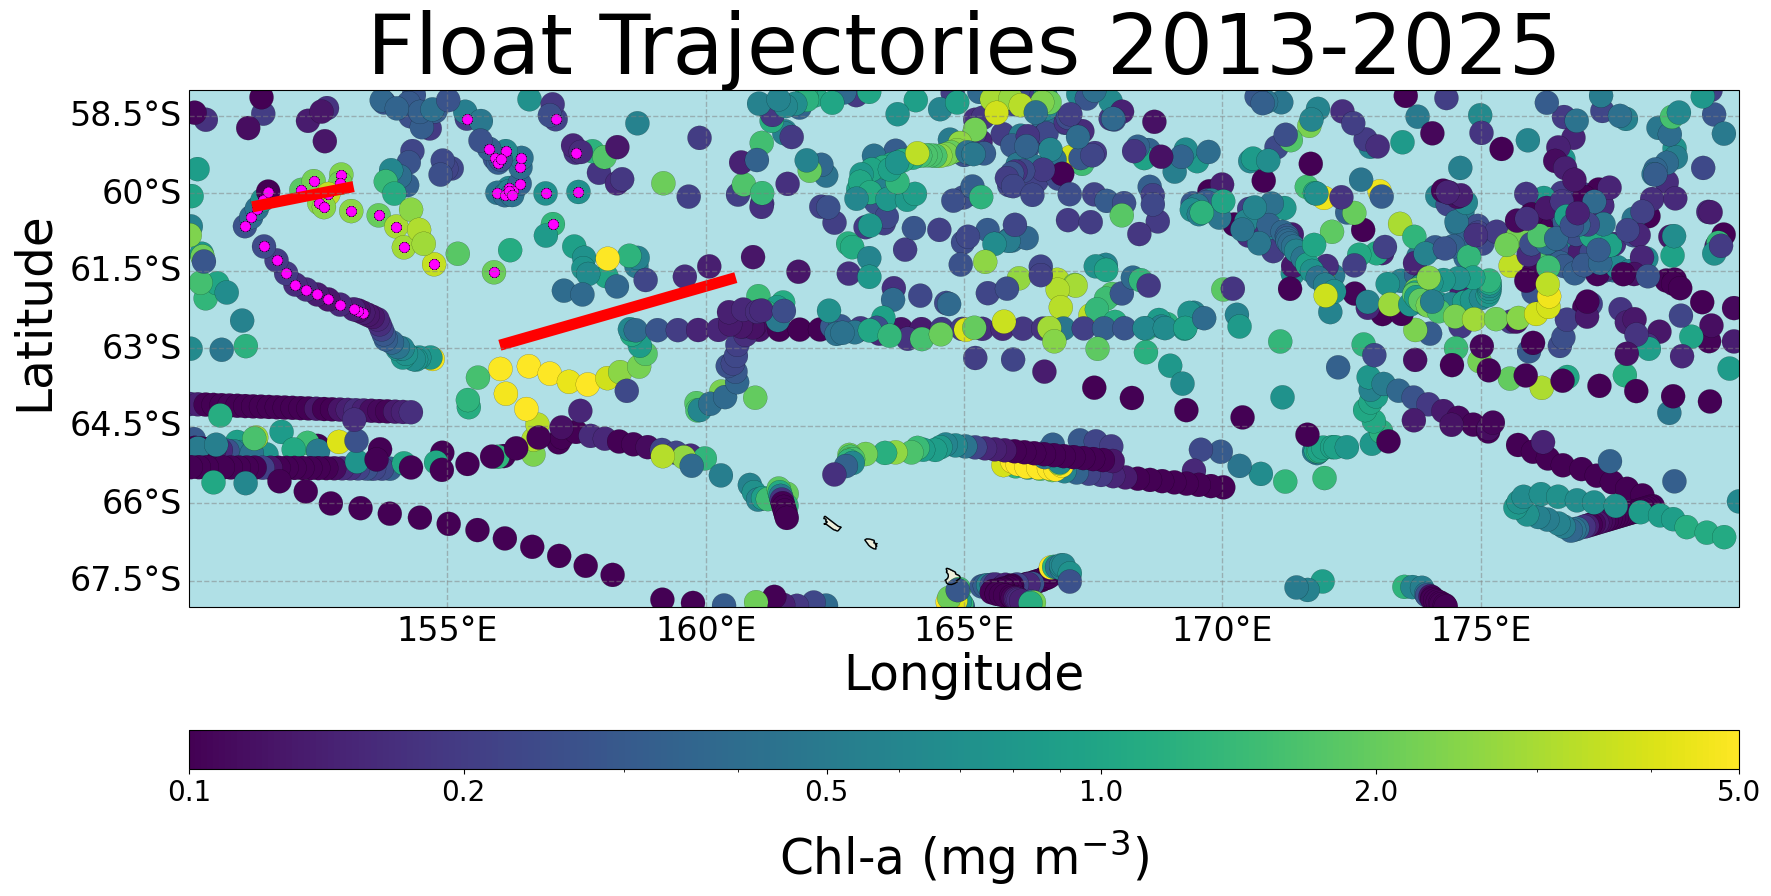

In [154]:
# things to fix: colorbar obviously, also how to make it just surface chla concentrations not the whole profile depth


fig = plt.figure(figsize=(20, 40))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN, color = 'powderblue')


df_chla = (pdf_clean.loc[pdf_clean.groupby(['WMOID', 'CYCLE_NUMBER'])['CHLA_ADJUSTED'].idxmax()])
    
    
sc = ax.scatter(df_chla['LONGITUDE'], df_chla['LATITUDE'],c=df_chla['CHLA_ADJUSTED'],
        cmap='viridis',s=300,transform=ccrs.PlateCarree(),norm=LogNorm(vmin=0.1, vmax=5), edgecolor='k', linewidth=0.1)

    
sc1 = ax.scatter(df['LONGITUDE'], df['LATITUDE'],c='magenta',
        s=50,transform=ccrs.PlateCarree(),edgecolor='k', linewidth=0.1)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04, aspect =40)
cbar.set_label('Chl-a (mg m$^{-3}$)', labelpad=15, fontsize = 35)
cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
cbar.formatter = FormatStrFormatter("%.1f")
cbar.ax.tick_params(labelsize=20) 
cbar.update_ticks()

# Define start and end points for KR1 and KR2
start_lon1, start_lat1 = 151.33, -60.24
end_lon1, end_lat1 = 153.08, -59.89
start_lon2, start_lat2 = 156.12, -62.91
end_lon2, end_lat2 = 160.48, -61.66

# Plot diagonal line on map
ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=8, linestyle='-', transform=ccrs.PlateCarree())
ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=8, linestyle='-', transform=ccrs.PlateCarree())

ax.set_extent([150, 180, -68, -58], crs=ccrs.PlateCarree()) # just data region

lat = [-63.164055, -62.79286]
lon = [163.932868, 169.976922]
gl =ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 24, 'color': 'black'}
gl.ylabel_style = {'size': 24, 'color': 'black'}
ax.set_title('Float Trajectories 2013-2025', fontsize=60)

ax.text(0.5, -0.16, 'Longitude', transform=ax.transAxes, ha='center', fontsize =35)
ax.text(-0.1, 0.4, 'Latitude', transform=ax.transAxes, ha='center', rotation=90,  fontsize =35)

# cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.03)
# cbar.set_label('Chl-a (mg m$^{-3}$)', labelpad=15)
# cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
# cbar.formatter = FormatStrFormatter("%.1f")
# cbar.update_ticks()

plt.show()

fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/all_float_traj_all_time_2013-2025.pdf', dpi=1000, transparent=True, bbox_inches='tight')